[<img src="images/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/si-md2/blob/main/si-md2/notebooks_alunos/cap05/cap05_aluno.ipynb)
[<img src="images/github-badge.png" style="width:20%; vertical-align:middle;">](https://github.com/fzampirolli/si-md2)

# Máquina de Vetores de Suporte ou *Support Vector Machine*

## Introdução

Nas unidades anteriores, foi usado o recurso de representar um **Exemplo de Treinamento** por um ponto num plano cartesiano, como no caso da flor Íris ([Figura 5.1](#fig-5-1)). As Regras de Classificação, por sua vez, eram representadas por retas tracejadas e ilustravam como o **Modelo Aprendido** classificava os Exemplos.

<figure id="fig-5-1" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-1.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.1:</strong> Representação de Exemplos de Treinamento no Plano Cartesiano <sup title="1">[1]</sup> <sup title="2">[2]</sup> <sup title="3">[3]</sup>.</figcaption>
</figure>







<hr><div style="font-size: 0.85em; color: #555;"><strong>Notas:</strong><br>
[1] Fonte: <a href="http://en.wikipedia.org/wiki/File:Iris_virginica.jpg">Wikimedia Commons - Iris virginica</a>     (Acessado em 03.03.26).<br>
[2] Fonte: <a href="http://en.wikipedia.org/wiki/File:Iris_versicolor_3.jpg">Wikimedia Commons - Iris versicolor</a>     (Acessado em 03.03.26).<br>
[3] Fonte: <a href="http://en.wikipedia.org/wiki/File:Kosaciec_szczecinkowaty_Iris_setosa.jpg">Wikimedia Commons - Iris setosa</a>     (Acessado em 03.03.26).<br>
</div>

Tanto as **Regras de Associação** e **Classificação** quanto as **Árvores de Decisão** podem ser vistas como representantes de um paradigma de aprendizado supervisionado denominado **Aprendizado Orientado a Conhecimento**, porque são de fácil compreensão e utilização pelos seres humanos. Outro nome que se dá a este tipo de aprendizado é **Paradigma de Aprendizado Simbólico**, porque ele cria **Representações Simbólicas do Modelo** gerado, tais como Árvores de Decisão, Regras etc.

Vamos agora estudar um novo paradigma de aprendizado supervisionado, conhecido como **Paradigma de Modelos Funcionais**, que em geral apresenta resultados com melhor precisão que os representantes do paradigma Orientado a Conhecimento, mas que para entender como se chegou a determinado resultado há que ter um certo preparo em matemática. Este tipo de aprendizado também é conhecido como **Paradigma do Aprendizado Estatístico**, porque ele utiliza **Modelos Estatísticos** para guiar a geração do Modelo induzido durante o treinamento.

Como o escopo desta unidade não é a apresentação da teoria matemática dessa classe de algoritmos, vamos reduzir a um mínimo as deduções matemáticas e nos valer de ilustrações gráficas e interpretações geométricas das ideias fundamentais deste interessante tópico.

Dois dos algoritmos de aprendizado supervisionado mais populares dos Modelos Funcionais, são as **Redes Neurais**<sup title="4">[4]</sup> ou *Neural Networks*, e as **Máquinas de Vetores** **de Suporte** ou *Support Vector Machine*. A teoria matemática sobre as Máquinas de Vetores de Suporte foi apresentada à comunidade científica por (Cortes e Vapnik (1995)), em meados da década de 1990, e desde então suas implementações algorítmicas têm produzido resultados animadores para o problema do **reconhecimento de padrões** em Bases de Dados.



<hr><div style="font-size: 0.85em; color: #555;"><strong>Notas:</strong><br>
[4] Em inglês, o termo “neural” é usado tanto para tópicos do sistema nervoso quanto para neurônios. Em português, no entanto, temos dois adjetivos distintos: neuronal e neural, sendo este último relacionado a nervos e ao sistema nervoso em geral. Como a inspiração inicial para as “<em>neural networks</em>” foram os neurônios, a tradução mais adequada para o português deveria ser “redes neuronais”, mas como “redes neurais” acabou prevalecendo, vamos manter esta terminologia.<br>
</div>

## Representação dos Exemplos como Vetores

Nesta introdução a **Máquinas de Vetores de Suporte** (**MVS**), vamos
passar a representar um **Exemplo de Treinamento** por um vetor, e o
**Modelo Aprendido**, por outro vetor, chamado de **Vetor Peso** $\mathbf{w}$.
Qual a vantagem dessa forma de representação? A vantagem é que para
classificar um Exemplo, bastará fazer o produto de dois vetores, algo
computacionalmente simples. No contexto de classificação com MVS,
mostraremos que o resultado dessa multiplicação será sempre ou "$+1$" ou
"$-1$". Dessa forma, por meio da operação de **produto interno** entre
dois vetores, os **Exemplos de Teste** serão classificados como
pertencentes ou à classe "$y = +1$" ou à "$y = -1$".

Embora o algoritmo de aprendizado de um Modelo Funcional seja bem
diferente daqueles algoritmos de aprendizado Orientado a Conhecimento, a
formalização do problema da classificação continua a mesma. Em termos
práticos, estamos simplesmente substituindo um módulo de classificação
por outro, que desempenha a mesma função, possivelmente de forma mais
complexa, porém com melhores resultados para muitos casos.

Um classificador binário é equivalente a uma função que faz o mapeamento
de um conjunto de **atributos de entrada**, agora representados por um
vetor $\mathbf{x}$, em uma das classes "$y = +1$" ou "$y = -1$". Em termos
matemáticos,

<a id="eq-5"></a>
$$
y = f(\mathbf{x}), \qquad y \in \{-1,\ +1\} \qquad \text{e} \qquad \mathbf{x} \in \mathbb{R}^{N} \tag{5.1}
$$


Por exemplo, num plano cartesiano, um ponto $\mathbf{x} \in \mathbb{R}^{2}$
pode ser descrito tanto por suas coordenadas $(x_1, x_2)$, quanto por um
vetor. Por esta razão, daqui para frente, em vez de utilizarmos o termo
Exemplos de Treinamento, vamos falar em **Vetores de Treinamento** (cuja
ilustração aparece na [Figura 5.2](#fig-5-2)). Da mesma forma, falaremos em **Vetores
de Teste** em vez de Exemplos de Teste.

Para efeito didático, consideraremos um ponto no plano ou um vetor como
representações equivalentes, e usaremos sempre a representação mais
conveniente para o argumento em questão.

Por opção metodológica, vamos comparar as MVS com as Redes Neurais, com
o propósito de mostrar como algumas das dificuldades mais sérias
apresentadas pelas Redes Neurais têm sido superadas com as MVS. Mas,
aproveitamos para reafirmar uma constatação empírica mencionada em outra
unidade de que em Mineração de Dados não existe um algoritmo que sempre
mostre desempenho superior aos demais para qualquer Base de Dados.
Muitos autores consideram a Mineração de Dados mais uma arte que uma
ciência, porque via de regra é preciso certo traquejo do operador e uma
boa dose de experimentos empíricos para melhorar os resultados práticos.

Aliás, um dos objetivos deste livro de **Sistemas Inteligentes**, e
especialmente desta unidade, é propiciar experiências que favoreçam o
desenvolvimento da sensibilidade indispensável a um usuário competente
da **Mineração de Dados**.

<figure id="fig-5-2" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-2.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.2:</strong> Representação de Vetores de Treinamento no Plano Cartesiano.</figcaption>
</figure>

## Classificadores Lineares

Vamos voltar ao conjunto de dados da flor Íris, porque este exemplo
clássico apresenta situações típicas de um problema de classificação
real. Olhando a [Figura 5.1](#fig-5-1), nota-se que não há qualquer dificuldade para
distinguir a Íris Setosa das Íris Versicolor e Virgínica. Mas a situação
é bem diferente quando consideramos a Íris Versicolor com a Virgínica,
porque há uma região comum a ambas. Encontrar um classificador que
separe linearmente estes dois tipos de Íris constitui uma tarefa nada
simples.

Vamos então dividir o problema em duas partes e considerar inicialmente
apenas os tipos Setosa e Versicolor, já que a separação entre ambas
parece ser bem mais simples. Com os resultados obtidos para os casos
linearmente separáveis, vamos estendê-los aos casos não separáveis
linearmente, com algumas adaptações.

A [Figura 5.3](#fig-5-3) apresenta os dados apenas da Íris Setosa e Versicolor, com
vários **classificadores** possíveis. Qual deles devemos escolher?

<figure id="fig-5-3" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-3.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.3:</strong> Qual Classificador Escolher?</figcaption>
</figure>

Talvez antes de dar uma resposta a esta pergunta, seria oportuno colocar
outra questão ainda mais básica. Por que tentar fazer a separação entre
as classes usando uma reta e não uma curva que se adapte aos dados?
Porque usar uma reta, ou uma função linear para separar classes é
matematicamente menos custoso do que outras formas de curvas, ou funções
polinomiais, além de tornar o problema do *overfitting* menos provável.
A equação de uma reta exige um tratamento matemático simples, resultando
num custo computacional mais baixo do que o custo dos polinômios de grau
maior ou igual a dois.

Dentre todas as possibilidades, o classificador azul parece ser o menos
indicado porque ele comete vários erros de classificação durante o
treinamento. Seu poder de generalização já se mostra antecipadamente
comprometido. Mas dentre os restantes, qual deles vai apresentar o
melhor desempenho na fase de teste? Ou seja, qual deles tem a melhor
capacidade de generalização? Será este o melhor critério a utilizar para
escolher um classificador?

Em outros algoritmos de Aprendizado Supervisionado de Classificadores
Lineares, como o Perceptron<sup title="5">[5]</sup> (Rosenblatt (1957)), os três
classificadores da Figura 5.3 que não cometem erros de classificação
durante o treinamento seriam considerados igualmente bons. Aliás, como
na resposta do Perceptron, e das **Redes Neurais** em geral, há um
**componente probabilístico**, em cada simulação com o mesmo conjunto de
Vetores de Treinamento, qualquer uma das três retas poderia ser
escolhida alternadamente como o classificador linear. Para o Perceptron,
desde que um classificador linear faça a separação das classes sem
cometer erros durante o treinamento, ele é tão bom quanto seus pares que
mostrarem o mesmo resultado.



Para as **MVS**, no entanto, que utilizam um **algoritmo determinístico**,
existe um classificador considerado melhor que todos os demais, porque
ele possivelmente vai minimizar os erros de classificação na fase de
teste. E este classificador é o que maximiza suas margens, tornando-as
as mais largas possíveis antes de tocar os primeiros pontos do plano,
que representam os **Vetores de Suporte** ([Figura 5.4](#fig-5-4)). Note que o
**vetor peso** $\mathbf{w}$, também conhecido como **vetor normal**
$\mathbf{w}$, é perpendicular à reta que representa o classificador.
Portanto, conhecendo-se o vetor $\mathbf{w}$, a inclinação do
classificador estará determinada.

Note que o classificador vermelho da [Figura 5.3](#fig-5-3), por exemplo, também
separaria sem erros as duas classes, mas suas margens não seriam tão
largas quanto as mostradas na [Figura 5.4](#fig-5-4). E como encontrar este
classificador que maximiza as margens? Primeiramente considerando o
conjunto de pontos como um **Conjunto Convexo**, e depois encontrando a
menor distância entre eles. A reta de separação, i.e., o classificador,
é perpendicular ao menor segmento que une os dois conjuntos.

<figure id="fig-5-4" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-4.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.4:</strong> Nas MVS, o Melhor Classificador Possui Margem Máxima.</figcaption>
</figure>

<hr><div style="font-size: 0.85em; color: #555;"><strong>Notas:</strong><br>
[5] O <em>Perceptron</em> é um tipo de Rede Neural simples, com apenas uma camada de neurônios.<br>
</div>

## Conjunto Convexo

Se conectarmos cada ponto de um conjunto aos demais pontos restantes, o
polígono externo que resulta será um polígono convexo, e o conjunto de
pontos delimitados por este polígono será chamado de **conjunto convexo**.

A [Figura 5.5](#fig-5-5) mostra como as duas classes de Vetores de Treinamento podem
ser representadas por dois conjuntos convexos (com as conexões dos
pontos internos omitidas para tornar mais clara a apresentação).

<figure id="fig-5-5" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-5.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.5:</strong> Representação das Classes como Conjuntos Convexos.</figcaption>
</figure>

A vantagem de se considerar as classes como se fossem dois conjuntos
convexos é que na busca pelo menor segmento que une estes dois
conjuntos, não ocorre o problema do **mínimo local**. Enquanto a
distância entre ambos estiver diminuindo, a direção seguida estará
correta.

A analogia para este procedimento é que o **Algoritmo de Aprendizado**
pode ser visto como um método de otimização <sup title="6">[6]</sup> de uma **Função Custo**.
A cada iteração do processo de aprendizado a Função Custo é avaliada e,
se seu valor decrescer, os pesos do vetor peso $\mathbf{w}$ são
atualizados. O processo continua até encontrar o valor mínimo.



Esta forma de otimização produz bons resultados quando a Função Custo
não apresenta mínimos locais, i.e., quando há apenas um **mínimo
global**. No caso das Redes Neurais, geralmente a Função Custo apresenta
mínimos locais, o que obriga a adoção de mecanismos mais complexos de
otimização, como manter alguns registros do que se acredita ser o mínimo
global atual, e continuar atualizando os pesos do vetor $\mathbf{w}$
mesmo que a Função Custo esteja aumentando ([Figura 5.6](#fig-5-6)).

Se um novo mínimo for encontrado, os registros antigos são apagados e
novos valores de peso são adotados. Embora este procedimento heurístico
aumente as possibilidades de detectar o mínimo global, não há nenhuma
garantia de que ele será encontrado, a menos que se pague um alto custo
computacional com uma busca exaustiva.

<figure id="fig-5-6" style="text-align:center; margin:1em 0;">
  <table style="width:100%; border:none;"><tr style="border:none;"><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-5-6a.png" style="width:100%;" /><br/><small>(a) Com Mínimo Local.</small></td><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-5-6b.png" style="width:100%;" /><br/><small>(b) Sem Mínimo Local.</small></td></tr></table>
  <figcaption><strong>Figura 5.6:</strong> Função Custo.</figcaption>
</figure>

<hr><div style="font-size: 0.85em; color: #555;"><strong>Notas:</strong><br>
[6] Este método é conhecido como <strong>Otimização Convexa</strong>.<br>
</div>

## Classificadores Não Lineares

Se as duas classes não forem linearmente separáveis, a teoria de MVS prevê o mapeamento dos pontos do **Espaço de Entrada** para outro espaço de maior dimensão, conhecido como **Espaço de Característica**. A [Figura 5.7](#fig-5-7) mostra uma situação em que os dados não podem ser linearmente separados. Para fazer a separação entre ambas podemos usar não uma reta, mas uma curva descrita por uma função polinomial, ou tentar um recurso matemático conhecido como **Truque do Núcleo** ou ***Kernel Trick***.

O uso de funções polinomiais, além de apresentar risco de alto custo computacional, pode favorecer o ajuste excessivo da curva polinomial aos Vetores de Treinamento, podendo então ocorrer problemas de ***overfitting*** decorrente da **instabilidade** causada pela enorme influência que um ou outro vetor pode ter sobre a curva polinomial. Já o princípio de **margem máxima** das MVS traz mais **estabilidade** na classificação, diminuindo as chances de *overfitting*. Para entender melhor este comportamento, vamos primeiramente ver o que significa usar um *kernel* <sup title="7">[7]</sup>.




<figure id="fig-5-7" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-7.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.7:</strong> Exemplo de Classes Não Separáveis Linearmente.</figcaption>
</figure>

<hr><div style="font-size: 0.85em; color: #555;"><strong>Notas:</strong><br>
[7] Embora o termo “<em>kernel</em>” possa ser perfeitamente traduzido para o português como “núcleo”, a tradução não parece ter prevalecido por aqui, sendo mais comum a utilização de <em>kernel</em>.<br>
</div>

A ideia por trás dos *kernels* é mapear os Vetores num espaço de
dimensão mais elevada que a original. Por exemplo, se o espaço original
dos Vetores de Entrada for bidimensional, podemos introduzir algumas
redundâncias em suas coordenadas e mapear estes mesmos vetores num
espaço tridimensional. Qual o propósito disso? É que duas classes não
separáveis linearmente num espaço bidimensional podem se tornar
linearmente separáveis num espaço tridimensional, como ilustra a
[Figura 5.8](#fig-5-8).

<figure id="fig-5-8" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-8.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.8:</strong> Exemplo de Transformação Não Linear do Espaço de Entrada para o Espaço de Características.</figcaption>
</figure>

Essa transformação em que os vetores são representados num espaço de
dimensão mais elevada, geralmente é uma transformação não linear
$\varphi(\mathbf{x})$. O espaço de partida dessa transformação não linear é
conhecido como **Espaço de Entrada** e o espaço com dimensão mais alta é
conhecido como **Espaço de Características**.

O que se busca com esta transformação é linearizar o Espaço de
Características, e com isso tornar os dados linearmente separáveis. Pode
parecer paradoxal, mas através de uma transformação não linear é
possível linearizar o Espaço de Características.

Vamos reproduzir um exemplo, apresentado por Sch{\"o}lkopf e Smola (2001), ilustrando
como esta transformação não linear pode ser feita. Suponha um **Espaço
de Entrada bidimensional**, composto por duas classes não separáveis
linearmente. Aplicando-se o truque do *kernel*, vamos mapear esses dados
num **Espaço de Características tridimensional**, como ilustrado na
[Figura 5.9](#fig-5-9).

Observando-se o resultado da operação mostrada na [Figura 5.9](#fig-5-9),
verifica-se que a **transformação não linear** $\varphi(\mathbf{x})$ não
criou novas variáveis; ainda estamos trabalhando com $x_1$ e $x_2$ no
início e no fim da transformação. As variáveis $z_1$, $z_2$ e $z_3$ são
apenas elementos intermediários que ajudam no entendimento da
transformação operada nos dados. Isso significa que não será necessário
computar explicitamente a transformação $\varphi(\mathbf{x})$ para
obtermos no Espaço de Entrada resultados semelhantes àqueles que
obteríamos se as operações tivessem sido feitas no Espaço de
Características.

<figure id="fig-5-9" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-9.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.9:</strong> Exemplo de Transformação Não Linear do Espaço de Entrada para o Espaço de Características.</figcaption>
</figure>

O **truque do *kernel*** permite que as operações de **produto interno**
entre dois vetores no Espaço de Características sejam computadas como se
ainda estivéssemos no Espaço de Entrada. Como, para efeitos práticos,
não houve efetivamente aumento da dimensão do espaço onde ocorrem as
operações de produto interno, o truque do *kernel* oferece a
possibilidade de escapar das complicações que as operações no Espaço de
Características poderiam trazer. Por isso, os matemáticos dizem que
*kernels* podem ajudar fugir da **Praga da Dimensionalidade**.

Existem vários *kernels* conhecidos (*Polynomial*, RBF etc.), alguns
desenvolvidos para aplicações específicas, como *kernels*
para bioinformática, para classificação de imagens ou caracteres etc.
Como as MVS se enquadram no paradigma do aprendizado supervisionado,
isso significa que existe um Conjunto de Vetores de Treinamento, cujos
rótulos de classe são previamente conhecidos. Portanto, com um pouco de
teoria e uma dose de experimentação é possível desenvolver *kernels* que
aumentem a taxa de sucesso durante o treinamento.

Se o Conjunto de Treinamento for uma amostra representativa dos Vetores
de Teste, então uma alta taxa de sucesso no treinamento possivelmente
significará boa capacidade de generalização para o teste. Caso
contrário, não será possível fazer previsões confiáveis com relação à
taxa de sucesso nos testes.

## Margem Suave Máxima

Há casos porém em que mesmo com a linearização do Espaço de
Características, obtida com o truque do *kernel*, as classes continuarão
não separáveis linearmente. O que fazer nessa situação?

A solução adotada pelas MVS foi criar uma "**margem suave**" que admite
ruídos, mas estabelece uma penalidade para cada caso de classificação
equivocada. Considere um parâmetro $C$, chamado de **Parâmetro de
Complexidade** $C$, que aplica uma pena a cada vetor classificado
erroneamente. A [Figura 5.10](#fig-5-10) ilustra diversas situações envolvendo
violações das bordas de classificação.

Se considerarmos primeiramente as margens verdes tracejadas do
classificador da [Figura 5.10](#fig-5-10), notamos que embora os vetores 1 e 2 tenham
violado os limites das margens verdes, eles estão classificados do lado
correto do plano. Os vetores 3, 4 e 5, por sua vez, estão do lado oposto
ao que deveriam estar. Portanto, a penalização para estes casos
distintos deve ser diferenciada, de acordo com a distância da margem.

O ajuste do **parâmetro** $C$ ajuda a encontrar um **compromisso entre a
tolerância a vetores classificados erroneamente** devido a margens
amplas (valor de $C$ baixo) **e a minimização dos erros de treinamento**
(valor de $C$ alto, e margens estreitas). As margens verdes correspondem
a um Fator de Complexidade $C$ baixo (${\sim}1$), enquanto que as
margens vermelhas correspondem a um valor de $C$ alto (${\sim}10$).

Note que a minimização dos erros de treinamento nem sempre é uma
garantia de elevada taxa de sucesso na fase de testes. Isso depende de
quão representativo é o Conjunto de Treinamento com relação ao Conjunto
de Teste, e do *kernel* escolhido. Para encontrar o melhor valor de $C$,
geralmente são coletados vários resultados empíricos usando o método da
*cross-validation*.

A [Figura 5.10](#fig-5-10) ainda ilustra o fato de que, uma vez encontrada a reta de
separação dos dados, apenas os Vetores de Suporte (aqueles pontos que
tocam as margens) passam a ter importância para a fase de testes. Todos
os demais Vetores de Treinamento podem ser desconsiderados porque eles
não têm qualquer influência sobre as margens. A implicação desse fato
para o desempenho do classificador é decisiva, uma vez que para
classificar um novo ponto no plano, basta considerar os Vetores de
Suporte, que são os delimitadores das margens.

<figure id="fig-5-10" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-10.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.10:</strong> Diferentes Margens com Diferentes Capacidades de Generalização.</figcaption>
</figure>

## Ferramental Matemático Básico

Vamos agora, de forma sucinta, dar uma ideia de como as bordas de
decisão de uma MVS podem ser obtidas matematicamente num espaço
bidimensional. Considere o plano cartesiano da [Figura 5.11](#fig-5-11) e os
respectivos vetores $\mathbf{x}$ e $\mathbf{w}$.

<figure id="fig-5-11" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-11.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.11:</strong> Produto Interno dos Vetores $\mathbf{w}$ e $\mathbf{x}$.</figcaption>
</figure>

O **Produto Interno** de dois vetores, também chamado de **Produto
Escalar** ou **Produto de Ponto**, gera como resultado uma grandeza
escalar, ou seja, um número real. Para sua representação, podemos usar
tanto um ponto, $\mathbf{w} \cdot \mathbf{x}$, quanto os sinais de
maior e menor, $\langle \mathbf{w}, \mathbf{x} \rangle$. As letras em
negrito representam um vetor, enquanto que as letras simples representam
uma grandeza escalar. Usando Produto Escalar, qualquer segmento de reta
pode ser representado no plano da forma mostrada na [Figura 5.12](#fig-5-12).

<figure id="fig-5-12" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-12.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.12:</strong> Equação da Reta: $\mathbf{w} \cdot \mathbf{x} + b = 0$.</figcaption>
</figure>

Para representar uma reta e suas margens, usamos o mesmo procedimento
([Figura 5.13](#fig-5-13)).

Como estamos interessados em maximizar as margens, ou seja, tornar o
módulo da subtração de $\mathbf{x}_1$ por $\mathbf{x}_2$,
$\|\mathbf{x}_1 - \mathbf{x}_2\|$, o mais largo possível, isso equivale
a minimizar o módulo do vetor peso $\mathbf{w}$, já que

<a id="eq-5-1"></a>
$$
\|\mathbf{x}_1 - \mathbf{x}_2\| = \frac{2}{\|\mathbf{w}\|} \tag{5.2}
$$


A [Equação 5.2](#eq-5-1) mostra que quanto menor o módulo de $\mathbf{w}$, mais largas
serão as margens!

<figure id="fig-5-13" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-13.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.13:</strong> Equação do Classificador e Margens.</figcaption>
</figure>

Dessa forma, a **Função de Aprendizado** de uma MVS consiste em "testar"
coordenadas para $\mathbf{w}$ de tal modo que seu módulo decresça a um
mínimo, fazendo com que as margens se alarguem, até o limite em que elas
toquem os primeiros Vetores de Treinamento nas bordas de decisão. Quando
isso ocorrer, estes Vetores de Treinamento que foram atingidos pelas
margens do classificador se tornam os **Vetores de Suporte** da MVS.

Existem técnicas matemáticas de otimização deste problema, por exemplo a
**Programação Quadrática**, bastante conhecida entre os matemáticos, e
que foram aproveitadas por Cortes e Vapnik (1995) para desenvolver o algoritmo da
MVS. Sucintamente o problema pode ser formalizado da forma exposta a
seguir.

Dado um **Conjunto de Treinamento**: $(\mathbf{x}_1, y_1),
(\mathbf{x}_2, y_2), \ldots, (\mathbf{x}_N, y_N)$

O **Hiperplano com Margem Máxima** é definido pelo par $(\mathbf{w}, b)$
que resolve o seguinte problema:

$$
\text{Minimize:} \quad \|\mathbf{w}\|^2
$$

$$
\text{Sujeito a:} \quad y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1, \quad \forall\, i = 1, \ldots, N
$$

Mais detalhes de como solucionar a forma dual desse problema de
Programação Quadrática podem ser obtidos na referência bibliográfica
desta unidade de estudo.

Há uma interessante implementação de MVS, proposta por Platt (1998),
conhecida como **SMO** (*Sequential Minimal Optimization*), que em vez
de considerar todos os Vetores de Treinamento conjuntamente, eles são
divididos em pares e seus valores ótimos são deduzidos analiticamente.
Embora o número de operações matemáticas aumente com relação à forma
mais tradicional de resolver numericamente o problema com um sistema de
equações, estas operações matemáticas da forma analítica são simples,
operações aritméticas básicas, e portanto muito rápidas num computador.
Dessa forma, o ganho no tempo total de computação pode ser significativo.

Outro atrativo muito interessante da implementação SMO é que não é
necessário carregar simultaneamente todos os Vetores de Treinamento na
memória principal do computador. Considerando aplicações reais, com
centenas de milhares ou milhões de Vetores de Treinamento, o algoritmo
SMO pode ser o mais indicado.

## Como Visualizar as Bordas de Decisão de uma MVS Usando o Weka

A ferramenta Weka (FRANK et al., 2016) permite rodar várias implementações de
**SVM**, ajustar o **Parâmetro de Complexidade** $C$, entre outros, e
visualizar as **Bordas de Decisão** obtidas.

**Passo 1 —** Primeiramente vamos carregar o arquivo "iris.arff" no Weka
e eliminar dois de seus Atributos, para tornar os resultados visualmente
mais interessantes. Carregue no "Weka Explorer" o arquivo "iris.arff"
(anexo), selecione os Atributos "sepallength" e "sepalwidth", e dê um
clique em "Remove", como mostra a [Figura 5.14](#fig-5-14).

> ### 💡 📂 Acesso ao Dataset Iris
>
> O arquivo `iris.arff` utilizado neste capítulo pode ser encontrado de duas formas:
>
> 1.  **Localmente:** Na pasta `/cap05` do repositório deste livro.
> 2.  **Online:** [Clique aqui para visualizar ou baixar via GitHub](https://github.com/fzampirolli/si-md2/blob/main/si-md2/cap05/iris.arff).


<figure id="fig-5-14" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-14.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.14:</strong> Remoção de Atributos de um Arquivo ".arff".</figcaption>
</figure>

Salve o novo arquivo com o nome "iris_mod.arff", dando um clique no
botão "Save\..." (no canto superior direito do "Weka Explorer").

**Passo 2 —** Vamos abrir o arquivo modificado "íris_mod.arff" no "Weka
GUI Chooser" ([Figura 5.15](#fig-5-15)), clicando primeiro na opção "Vizualization" e
depois em "BoundaryVisualizer".

<figure id="fig-5-15" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-15.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.15:</strong> Interface do "Weka GUI Chooser".</figcaption>
</figure>

Uma janela semelhante à mostrada na [Figura 5.16](#fig-5-16) deve aparecer.

<figure id="fig-5-16" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-16.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.16:</strong> Janela do "BoundaryVisualizer".</figcaption>
</figure>


**Passo 3** -- Clique no Botão "Open File", localize o arquivo
"íris_mod.arff" e carregue no "BoundaryVisualizer. Os Vetores de
Treinamento (representados por pontos) devem aparecer na tela de
visualização do "BoundaryVisualizer" ([Figura 5.17](#fig-5-17)). (Como o
"BoundaryVisualizer" leva em conta os ajustes da última vez em que ele
foi utilizado, a imagem que aparece na tela pode variar de simulação
para simulação.).

<figure id="fig-5-17" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-17.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.17:</strong> "BoundaryVizualizer.</figcaption>
</figure>

**Passo 4** -- Na parte superior direita, em "Classifier", clique em
"Choose" ([Figura 5.17](#fig-5-17)), escolha "Classifiers" , depois "functions" e,
finalmente "SMO", como ilustra a [Figura 5.18](#fig-5-18). Inicialmente deixe os
valores default do SMO.

<figure id="fig-5-18" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-18.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.18:</strong> Escolha do Algoritmo SMO.</figcaption>
</figure>


Marque a opção "Plot training data" ([Figura 5.18](#fig-5-18)), na parte inferior
direita, para que ao final da simulação apareçam não apenas as bordas de
decisão do classificador, mas também os dados usados no treinamento. Dê
um clique em "Start" ([Figura 5.18](#fig-5-18)).

Lentamente as bordas de decisão do classificador vão se formando,
enquanto uma linha horizontal corre a tela indicando que a simulação
está em progresso.


**Passo 5** -- O número de Vetores de Treinamento classificados
erroneamente deve ser em torno de 6. Vá com o mouse novamente na parte
superior direita do "BoundaryVisualizer" e clique com o botão da
esquerda sobre a palavra "SMO", ao lado de "Choose", no campo
"Classifieres". Uma janela de ajustes dos parâmetros do SMO, semelhante
à mostrada na [Figura 5.19](#fig-5-19), deve se abrir.

<figure id="fig-5-19" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-19.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.19:</strong> Janela de Ajustes de Parâmetros do SMO.</figcaption>
</figure>

Nesta janela, no botão "More" há uma explicação sucinta de todos
parâmetros mostrados.


**Passo 6 --** Faça novas simulações variando o valor default do
Parâmetro de Complexidade C de 1.0 para 2.0, 5.0, 30.0 etc. e confira o
número de Vetores de Treinamento que continuam classificados
erroneamente. Com ajuste de C = 2.0 e kernel "PolyKernel" foi rodada uma
simulação, cujos resultados são mostrados na [Figura 5.20](#fig-5-20).

<figure id="fig-5-20" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-20.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.20:</strong> "PolyKernel".</figcaption>
</figure>


Quando o valor do parâmetro C foi alterado para 91, as Bordas de Decisão
se alteraram, como mostra a [Figura 5.21](#fig-5-21).

<figure id="fig-5-21" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-21.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.21:</strong> Bordas de Decisão da Simulação para C = 2.0 e kernel "PolyKernel".</figcaption>
</figure>

Como pode ser observado, há dois ou três pontos verdes e azuis que se
parecem com "outliers". Vamos retirar alguns deles, ativando a opção
"Remove points" ([Figura 5.21](#fig-5-21)), e ver como a Borda de Decisão se altera.
A [Figura 5.22](#fig-5-22) mostra o resultado da remoção de alguns pontos azuis da
tela, usando o botão esquerdo do mouse.

<figure id="fig-5-22" style="text-align:center; margin:1em 0;">
  <img src="images/fig-5-22.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 5.22:</strong> Simulação com a Remoção de Alguns Pontos Perto das Bordas.</figcaption>
</figure>

Como pode ser observado na [Figura 5.22](#fig-5-22), a Borda de Decisão superior
sofreu uma alteração significativa, mostrando que Vetores de Treinamento
próximos das Margens têm um peso muito grande nos resultados obtidos.


**Passo 7** -- Novos kernels podem ser escolhidos entre os ajustes do
SMO. As cores do painel do "BoundaryVisualizer" podem ser alteradas,
clicando sobre os nomes das três "iris" no campo intermediário "Class
color". Outros ajustes interessantes podem ser feitos no
"BoundaryVisualizer" e testados em novas simulações. Bom trabalho!

## 🧪 Prática em Python

### Introdução

Neste capítulo, o tema central é a **Máquina de Vetores de Suporte (MVS)**,
um classificador do paradigma de Aprendizado Estatístico. Nas práticas a seguir,
usaremos o **Scikit-learn** para reproduzir em Python as simulações descritas
no texto: treinamento de uma MVS com kernel linear e RBF sobre o dataset Iris,
visualização das **Bordas de Decisão**, análise do **Parâmetro de Complexidade C**
e avaliação com **Validação Cruzada** — reproduzindo os experimentos realizados
no Weka com o algoritmo SMO.

### 🔹 Configuração do Ambiente

Todos os `import` são centralizados nesta célula. Certifique-se de executá-la
antes das práticas.

> ### ❗ Atenção: Dependência de Execução
>
> O conteúdo deste capítulo é sequencial. As variáveis e funções definidas
> aqui são requisitos para as práticas seguintes. Execute as células em ordem.

In [13]:
# 1. Instalação de dependências (Silenciosa)
!pip install scikit-learn > /dev/null

# 2. Supressão de Avisos
import warnings
warnings.filterwarnings("ignore")

# 3. Importações
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sklearn
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import confusion_matrix, accuracy_score
from IPython.display import Markdown, display

# 4. Verificação de versões
print(f"Python      : {sys.version.split()[0]}")
print(f"NumPy       : {np.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print("✅ Ambiente pronto!")

Python      : 3.9.7
NumPy       : 2.0.2
Matplotlib  : 3.9.4
Scikit-learn: 1.6.1
✅ Ambiente pronto!


### 🔹 Prática 1 — MVS Linear no Iris (Setosa vs. Versicolor)

A [Figura 5.3](#fig-5-3) do texto mostra que **Íris Setosa** e **Íris Versicolor** são
linearmente separáveis quando usamos os atributos de pétala. A MVS com
**kernel linear** encontra o hiperplano de **margem máxima** que separa
as duas classes — exatamente o conceito central do capítulo.

A [Figura 5.23](#fig-5-pratica1) reproduz a [Figura 5.4](#fig-5-4) do texto: o classificador com
margem máxima e os **Vetores de Suporte** destacados.

> ### ❗ Atenção: Dependência de Execução
>
> Esta prática depende do **bloco de importações** acima.

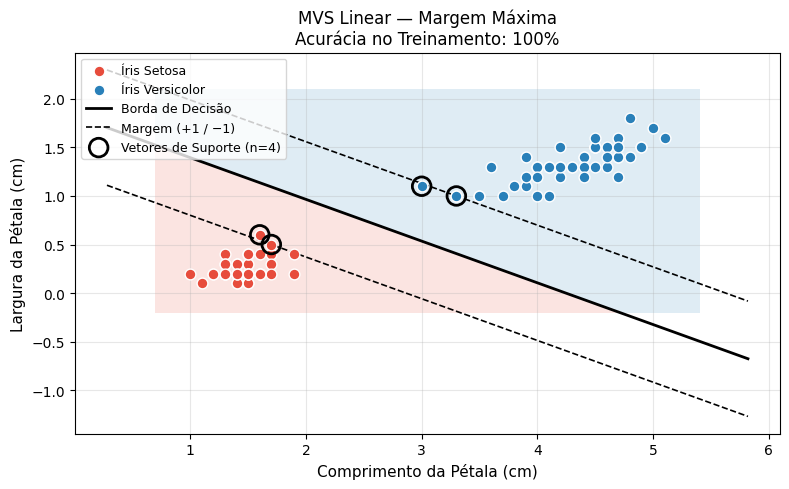

**Figura 5.23:** MVS Linear — Margem Máxima entre Íris Setosa e Versicolor (atributos de pétala).



📊 Vetores de Suporte : 4
   Acurácia (treino) : 100.00%
   Norma de w        : 1.4094  (quanto menor, maior a margem)
   Largura da margem : 1.4190 (no espaço normalizado)


In [14]:
# 1. Dataset: apenas Setosa (0) e Versicolor (1), atributos de pétala
iris = load_iris()
mask = iris.target < 2
X = iris.data[mask, 2:]          # petallength, petalwidth
y = iris.target[mask]             # 0=setosa, 1=versicolor
nomes = ["Íris Setosa", "Íris Versicolor"]
cores_cls = ["#e74c3c", "#2980b9"]

# 2. Treino da MVS com kernel linear
clf = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0))
clf.fit(X, y)
acuracia = clf.score(X, y)

# 3. Grade para visualização da Borda de Decisão
scaler = clf[0]
svm    = clf[1]
X_sc   = scaler.transform(X)

x1_min, x1_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
x2_min, x2_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                     np.linspace(x2_min, x2_max, 300))
grade_sc = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
Z = svm.predict(grade_sc).reshape(xx.shape)

# 4. Margem e vetores de suporte
w   = svm.coef_[0]
b   = svm.intercept_[0]
x1_line = np.linspace(X_sc[:, 0].min() - 0.5, X_sc[:, 0].max() + 0.5, 200)
# borda: w0*x1 + w1*x2 + b = 0  →  x2 = -(w0*x1 + b) / w1
x2_borda    = -(w[0] * x1_line + b) / w[1]
x2_margem_p = -(w[0] * x1_line + b - 1) / w[1]
x2_margem_n = -(w[0] * x1_line + b + 1) / w[1]

# Converte de volta para escala original
inv = scaler.inverse_transform
to_orig = lambda x1, x2: inv(np.c_[x1, x2])

borda_orig    = to_orig(x1_line, x2_borda)
margem_p_orig = to_orig(x1_line, x2_margem_p)
margem_n_orig = to_orig(x1_line, x2_margem_n)
sv_orig       = scaler.inverse_transform(svm.support_vectors_)

# 5. Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
ax.contourf(xx, yy, Z, alpha=0.15, cmap=mcolors.ListedColormap(cores_cls))

for cls, cor, nome in zip([0, 1], cores_cls, nomes):
    ax.scatter(X[y == cls, 0], X[y == cls, 1],
               c=cor, label=nome, edgecolors="white", s=60, zorder=3)

ax.plot(borda_orig[:, 0],    borda_orig[:, 1],    "k-",  lw=2,   label="Borda de Decisão")
ax.plot(margem_p_orig[:, 0], margem_p_orig[:, 1], "k--", lw=1.2, label="Margem (+1 / −1)")
ax.plot(margem_n_orig[:, 0], margem_n_orig[:, 1], "k--", lw=1.2)
ax.scatter(sv_orig[:, 0], sv_orig[:, 1],
           s=180, facecolors="none", edgecolors="black", linewidths=2,
           zorder=4, label=f"Vetores de Suporte (n={len(sv_orig)})")

ax.set_xlabel("Comprimento da Pétala (cm)", fontsize=11)
ax.set_ylabel("Largura da Pétala (cm)", fontsize=11)
ax.set_title(f"MVS Linear — Margem Máxima\nAcurácia no Treinamento: {acuracia:.0%}", 
             fontsize=12)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Vetores de Suporte : {len(svm.support_vectors_)}")
print(f"   Acurácia (treino) : {acuracia:.2%}")
print(f"   Norma de w        : {np.linalg.norm(w):.4f}  (quanto menor, maior a margem)")
print(f"   Largura da margem : {2 / np.linalg.norm(w):.4f} (no espaço normalizado)")

### 🔹 Prática 2 — Efeito do Parâmetro de Complexidade C

O **Parâmetro de Complexidade C** controla o compromisso entre **margem
larga** (C baixo, mais tolerante a erros) e **minimização dos erros de
treinamento** (C alto, margens estreitas). A [Figura 5.10](#fig-5-10) do texto ilustra
esse efeito visualmente.

A [Figura 5.24](#fig-5-pratica2) replica esse experimento em Python: para quatro valores
de C, são plotadas as bordas de decisão e contados os vetores de suporte,
usando o dataset Iris completo (3 classes, atributos de pétala).

> ### ❗ Atenção: Dependência de Execução
>
> Esta prática depende do **bloco de importações** e do **dataset Iris**
> carregado na Prática 1.

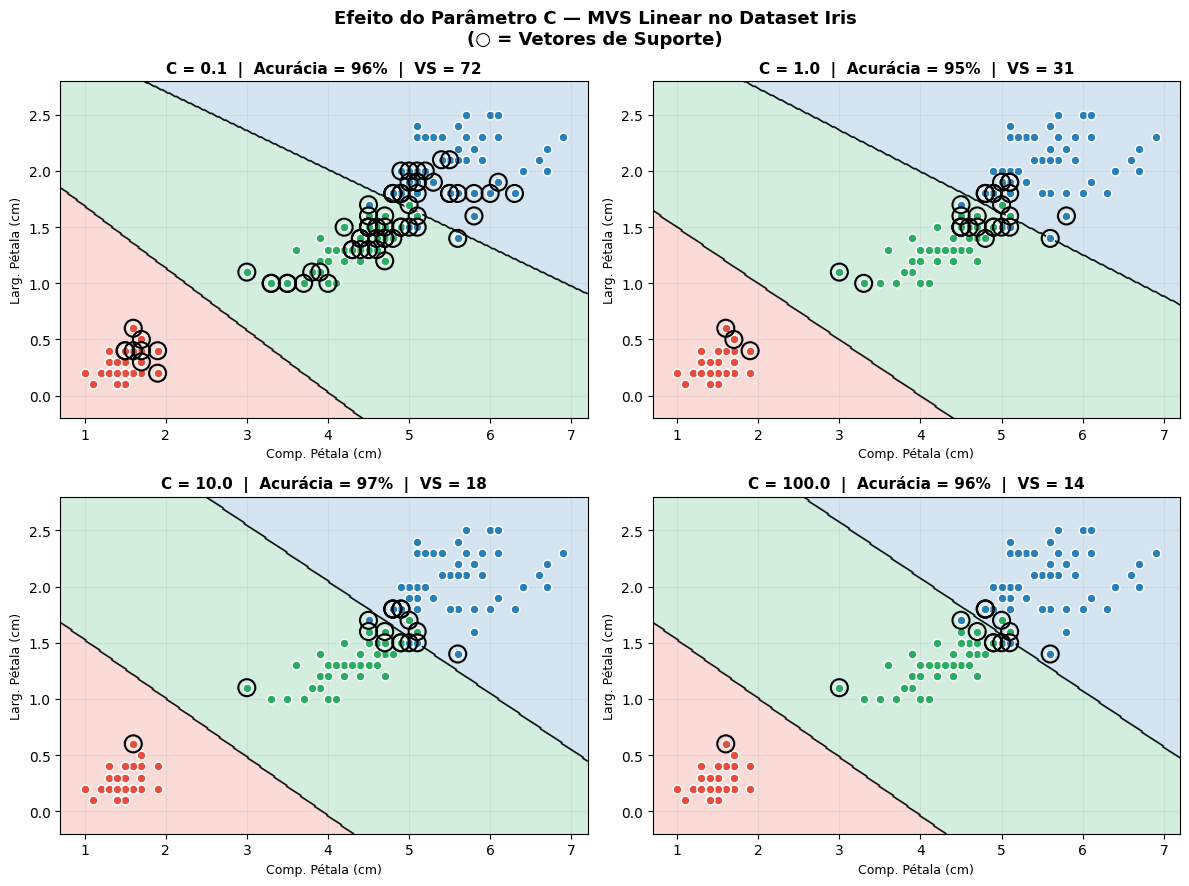

**Figura 5.24:** Efeito do Parâmetro C nas Bordas de Decisão da MVS (Iris, kernel linear).



📊 Resumo:
       C |   Acurácia |   Vetores de Suporte
---------------------------------------------
     0.1 |     96.00% |                   72
     1.0 |     95.33% |                   31
    10.0 |     96.67% |                   18
   100.0 |     96.00% |                   14


In [15]:
# Dataset completo (3 classes), atributos de pétala
X_full = iris.data[:, 2:]
y_full = iris.target
nomes_3 = iris.target_names
cores_3 = ["#e74c3c", "#27ae60", "#2980b9"]

valores_C = [0.1, 1.0, 10.0, 100.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

x1_min, x1_max = X_full[:, 0].min() - 0.3, X_full[:, 0].max() + 0.3
x2_min, x2_max = X_full[:, 1].min() - 0.3, X_full[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                     np.linspace(x2_min, x2_max, 300))

for ax, C in zip(axes, valores_C):
    modelo = make_pipeline(StandardScaler(), SVC(kernel="linear", C=C))
    modelo.fit(X_full, y_full)
    ac = modelo.score(X_full, y_full)
    n_sv = sum(len(v) for v in modelo[1].support_vectors_.reshape(1, -1))
    n_sv = len(modelo[1].support_vectors_)

    Z = modelo.predict(
        np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2,
                cmap=mcolors.ListedColormap(cores_3))
    ax.contour(xx, yy, Z, colors="black", linewidths=0.8, alpha=0.5)

    for cls, cor in zip([0, 1, 2], cores_3):
        ax.scatter(X_full[y_full == cls, 0], X_full[y_full == cls, 1],
                   c=cor, edgecolors="white", s=40, zorder=3)

    sv = modelo[0].inverse_transform(modelo[1].support_vectors_)
    ax.scatter(sv[:, 0], sv[:, 1], s=150, facecolors="none",
               edgecolors="black", linewidths=1.5, zorder=4)

    ax.set_title(f"C = {C}  |  Acurácia = {ac:.0%}  |  VS = {n_sv}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Comp. Pétala (cm)", fontsize=9)
    ax.set_ylabel("Larg. Pétala (cm)", fontsize=9)
    ax.grid(True, alpha=0.2)

fig.suptitle("Efeito do Parâmetro C — MVS Linear no Dataset Iris\n"
             "(○ = Vetores de Suporte)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n📊 Resumo:")
print(f"{'C':>8} | {'Acurácia':>10} | {'Vetores de Suporte':>20}")
print("-" * 45)
for C in valores_C:
    m = make_pipeline(StandardScaler(), SVC(kernel="linear", C=C))
    m.fit(X_full, y_full)
    print(f"{C:>8} | {m.score(X_full, y_full):>10.2%} | {len(m[1].support_vectors_):>20}")

### 🔹 Prática 3 — Comparação de Kernels (Linear, Polinomial e RBF)

O texto descreve como diferentes *kernels* mapeiam os dados para espaços
de maior dimensão, tornando classes não linearmente separáveis em
linearmente separáveis. A [Figura 5.25](#fig-5-pratica3) compara os três *kernels*
disponíveis no SMO do Weka — **Linear**, **Polinomial** e **RBF** —
reproduzindo o experimento dos Passos 6 e 7 do tutorial, agora com
as três classes do Iris completo.

> ### ❗ Atenção: Dependência de Execução
>
> Esta prática depende do **bloco de importações** e das variáveis
> `X_full` e `y_full` definidas na Prática 2.

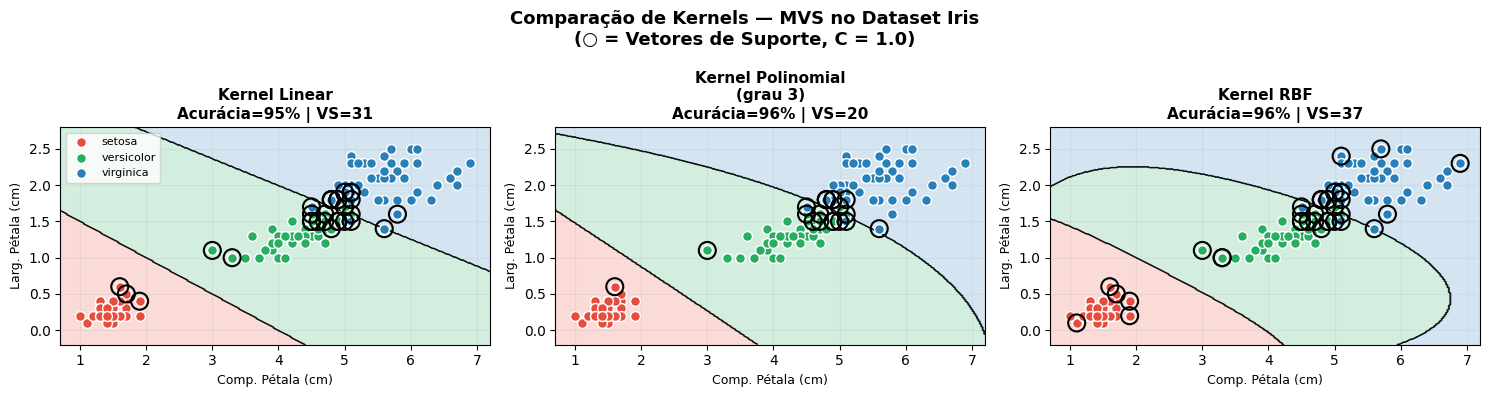

**Figura 5.25:** Comparação de Kernels da MVS no Dataset Iris (atributos de pétala).



📊 Resumo dos Kernels (C=1.0):
Kernel               |   Acurácia |   Vetores de Suporte
--------------------------------------------------------
Linear               |     95.33% |                             31
Polinomial (grau 3)  |     96.00% |                             20
RBF                  |     96.00% |                             37


In [16]:
kernels = [
    ("Linear",      SVC(kernel="linear",  C=1.0)),
    ("Polinomial\n(grau 3)", SVC(kernel="poly",    C=1.0, degree=3, coef0=1)),
    ("RBF",         SVC(kernel="rbf",     C=1.0, gamma="scale")),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nome, svc) in zip(axes, kernels):
    modelo = make_pipeline(StandardScaler(), svc)
    modelo.fit(X_full, y_full)
    ac = modelo.score(X_full, y_full)
    n_sv = len(modelo[1].support_vectors_)

    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap=mcolors.ListedColormap(cores_3))
    ax.contour(xx, yy, Z, colors="black", linewidths=0.8, alpha=0.5)

    for cls, cor, n in zip([0, 1, 2], cores_3, nomes_3):
        ax.scatter(X_full[y_full == cls, 0], X_full[y_full == cls, 1],
                   c=cor, edgecolors="white", s=50, zorder=3, label=n)

    sv = modelo[0].inverse_transform(modelo[1].support_vectors_)
    ax.scatter(sv[:, 0], sv[:, 1], s=150, facecolors="none",
               edgecolors="black", linewidths=1.5, zorder=4)

    ax.set_title(f"Kernel {nome}\nAcurácia={ac:.0%} | VS={n_sv}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Comp. Pétala (cm)", fontsize=9)
    ax.set_ylabel("Larg. Pétala (cm)", fontsize=9)
    ax.grid(True, alpha=0.2)

axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Comparação de Kernels — MVS no Dataset Iris\n"
             "(○ = Vetores de Suporte, C = 1.0)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n📊 Resumo dos Kernels (C=1.0):")
print(f"{'Kernel':<20} | {'Acurácia':>10} | {'Vetores de Suporte':>20}")
print("-" * 56)
for nome, svc in kernels:
    m = make_pipeline(StandardScaler(), svc.__class__(**svc.get_params()))
    m.fit(X_full, y_full)
    print(f"{nome.replace(chr(10),' '):<20} | {m.score(X_full,y_full):>10.2%} | \
          {len(m[1].support_vectors_):>20}")

### 🔹 Prática 4 — Validação Cruzada 10-fold com MVS (Exercício 3)

O exercício 3 do capítulo pede a classificação do Iris com o algoritmo
**SMO** usando **Cross-validation 10-fold**, variando o **fator C** e
comparando **PolyKernel** e **RBFKernel**. A [Figura 5.26](#fig-5-pratica4) reproduz
esse experimento em Python, usando o shuffle do Weka para garantir
resultados comparáveis.

> ### ❗ Atenção: Dependência de Execução
>
> Esta prática depende do **bloco de importações** e de `X_full`, `y_full`
> da Prática 2.

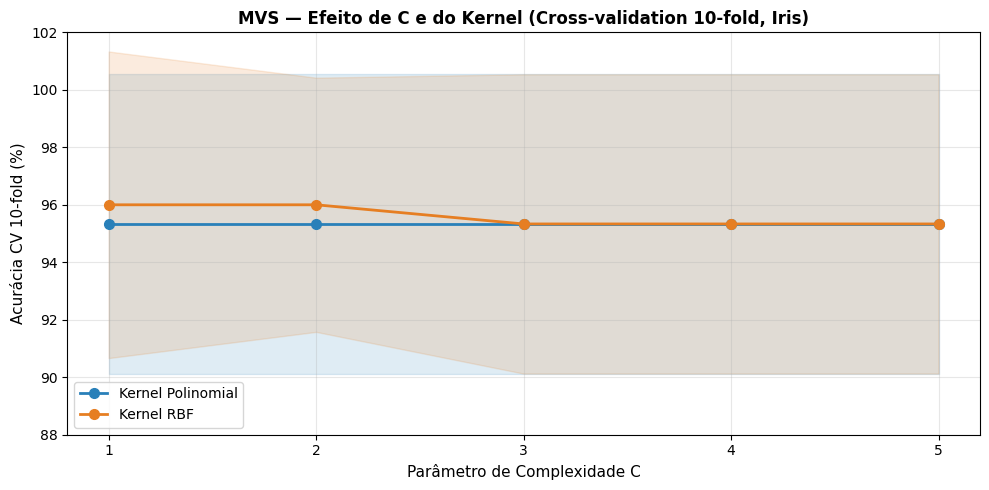

**Figura 5.26:** Cross-validation 10-fold com MVS — Efeito de C e do Kernel no Dataset Iris.



📊 Tabela Resumo — Acurácia CV 10-fold:
   C | Kernel       |    Média |   Desvio
----------------------------------------
   1 | Polinomial   |   95.33% |              5.21%
   1 | RBF          |   96.00% |              5.33%
   2 | Polinomial   |   95.33% |              5.21%
   2 | RBF          |   96.00% |              4.42%
   3 | Polinomial   |   95.33% |              5.21%
   3 | RBF          |   95.33% |              5.21%
   4 | Polinomial   |   95.33% |              5.21%
   4 | RBF          |   95.33% |              5.21%
   5 | Polinomial   |   95.33% |              5.21%
   5 | RBF          |   95.33% |              5.21%


In [17]:
# Reproduz shuffle do Weka (Java Random, seed=0) para CV comparável
def weka_shuffle(n, seed=0):
    indices = list(range(n))
    state = (seed ^ 0x5DEECE66D) & ((1 << 48) - 1)
    for i in range(n - 1, 0, -1):
        state = (state * 0x5DEECE66D + 0xB) & ((1 << 48) - 1)
        j = (state >> 17) % (i + 1)
        indices[i], indices[j] = indices[j], indices[i]
    return indices

perm = weka_shuffle(len(X_full), seed=0)
X_perm = X_full[perm]
y_perm = y_full[perm]
kf = KFold(n_splits=10, shuffle=False)

# --- Item (a): variar C com kernel Polinomial ---
valores_C_ex = [1, 2, 3, 4, 5]
resultados = []
for C in valores_C_ex:
    for kernel, label in [("poly", "Polinomial"), ("rbf", "RBF")]:
        modelo = make_pipeline(StandardScaler(),
                               SVC(kernel=kernel, C=C, degree=3,
                                   coef0=1, gamma="scale"))
        scores = cross_val_score(modelo, X_perm, y_perm, cv=kf,
                                 scoring="accuracy")
        resultados.append({"C": C, "Kernel": label,
                           "Média": scores.mean(), "DP": scores.std()})

df_res = pd.DataFrame(resultados)

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 5))
for kernel, cor in [("Polinomial", "#2980b9"), ("RBF", "#e67e22")]:
    sub = df_res[df_res["Kernel"] == kernel]
    ax.plot(sub["C"], sub["Média"] * 100, "o-", color=cor,
            linewidth=2, markersize=7, label=f"Kernel {kernel}")
    ax.fill_between(sub["C"],
                    (sub["Média"] - sub["DP"]) * 100,
                    (sub["Média"] + sub["DP"]) * 100,
                    alpha=0.15, color=cor)

ax.set_xlabel("Parâmetro de Complexidade C", fontsize=11)
ax.set_ylabel("Acurácia CV 10-fold (%)", fontsize=11)
ax.set_title("MVS — Efeito de C e do Kernel (Cross-validation 10-fold, Iris)",
             fontsize=12, fontweight="bold")
ax.set_xticks(valores_C_ex)
ax.set_ylim([88, 102])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabela resumo
print("\n📊 Tabela Resumo — Acurácia CV 10-fold:")
print(f"{'C':>4} | {'Kernel':<12} | {'Média':>8} | {'Desvio':>8}")
print("-" * 40)
for _, row in df_res.iterrows():
    print(f"{int(row['C']):>4} | {row['Kernel']:<12} | {row['Média']:>8.2%} | \
          {row['DP']:>8.2%}")

### 🔹 Prática 5 — Matriz de Confusão da MVS (C=1, RBF, Cross-validation)

Com o melhor kernel identificado na Prática 4, a [Figura 5.27](#fig-5-pratica5) detalha
a **Matriz de Confusão** completa da MVS com **kernel RBF** e **C=1**,
mostrando as taxas de Verdadeiro Positivo por classe — diretamente
comparável aos resultados do Weka para o item (b) do exercício 3.

> ### ❗ Atenção: Dependência de Execução
>
> Esta prática depende de `weka_shuffle`, `X_perm`, `y_perm` e `kf`
> definidos na Prática 4.

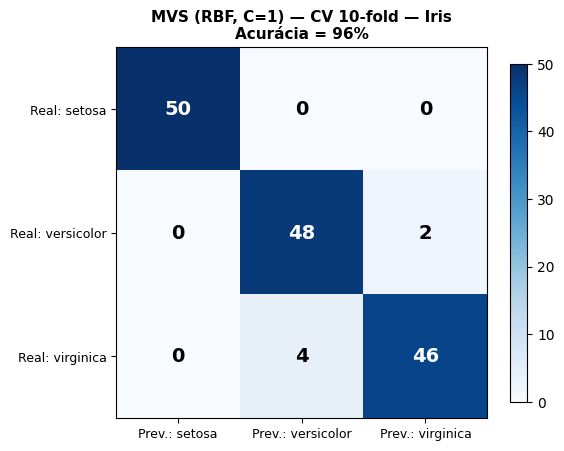

**Figura 5.27:** Matriz de Confusão — MVS RBF C=1 com Cross-validation 10-fold no Iris.



🌸 Acurácia Geral (CV 10-fold): 96.00%

   Taxa VP (        setosa): 100.00%  (50/50)
   Taxa VP (    versicolor): 96.00%  (48/50)
   Taxa VP (     virginica): 92.00%  (46/50)

💡 Comparação com outros kernels (C=1, CV 10-fold):
Kernel          |   Acurácia
------------------------------
Linear          |     96.00%
Polinomial      |     95.33%
RBF             |     96.00%


In [18]:
from sklearn.model_selection import cross_val_predict

modelo_rbf = make_pipeline(StandardScaler(),
                            SVC(kernel="rbf", C=1.0, gamma="scale"))
pred_cv = cross_val_predict(modelo_rbf, X_perm, y_perm, cv=kf)

mat = confusion_matrix(y_perm, pred_cv)
ac  = accuracy_score(y_perm, pred_cv)
nomes_iris = iris.target_names

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mat, cmap="Blues")
for i in range(3):
    for j in range(3):
        cor = "white" if mat[i, j] > mat.max() / 2 else "black"
        ax.text(j, i, str(mat[i, j]), ha="center", va="center",
                fontsize=14, fontweight="bold", color=cor)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([f"Prev.: {c}" for c in nomes_iris], fontsize=9)
ax.set_yticklabels([f"Real: {c}" for c in nomes_iris], fontsize=9)
ax.set_title(f"MVS (RBF, C=1) — CV 10-fold — Iris\nAcurácia = {ac:.0%}",
             fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print(f"\n🌸 Acurácia Geral (CV 10-fold): {ac:.2%}")
print()
for idx, cls in enumerate(nomes_iris):
    vp  = mat[idx, idx]
    tot = mat[idx].sum()
    print(f"   Taxa VP ({cls:>14}): {vp/tot:.2%}  ({vp}/{tot})")

print()
print("💡 Comparação com outros kernels (C=1, CV 10-fold):")
print(f"{'Kernel':<15} | {'Acurácia':>10}")
print("-" * 30)
for kernel, label in [("linear","Linear"),("poly","Polinomial"),("rbf","RBF")]:
    m = make_pipeline(StandardScaler(),
                      SVC(kernel=kernel, C=1.0, degree=3, coef0=1, gamma="scale"))
    sc = cross_val_score(m, X_perm, y_perm, cv=kf, scoring="accuracy")
    print(f"{label:<15} | {sc.mean():>10.2%}")

### Conclusão do Ciclo de Aprendizado

Através destas cinco práticas, percorremos a jornada completa de uma MVS:

1. **MVS Linear e Margem Máxima** — Visualizamos a borda de decisão e os
   Vetores de Suporte para o caso linearmente separável (Setosa vs. Versicolor),
   confirmando o princípio de margem máxima descrito no texto.

2. **Efeito do Parâmetro C** — Observamos como C baixo produz margens largas
   e mais Vetores de Suporte, enquanto C alto reduz os erros de treinamento
   à custa de margens mais estreitas.

3. **Comparação de Kernels** — Demonstramos como Linear, Polinomial e RBF
   produzem bordas de decisão distintas para o problema de 3 classes do Iris.

4. **Cross-validation e escolha de C** — Reproduzimos o experimento do
   exercício 3 variando C de 1 a 5, comparando PolyKernel e RBFKernel com
   validação cruzada 10-fold no shuffle do Weka.

5. **Matriz de Confusão** — Detalhamos a performance por classe da melhor
   configuração encontrada, com taxas de Verdadeiro Positivo comparáveis
   aos resultados do SMO no Weka.

## 🤖 Uso do NotebookLM como Tutor Complementar

Seguindo o padrão dos capítulos anteriores, além dos notebooks interativos
no Google Colab, incentiva-se o uso do **NotebookLM** como ferramenta
complementar de aprendizagem.

> ### ❗ 🎓 Estude com o Tutor Inteligente
>
> Para interagir com o conteúdo deste capítulo, acesse o link abaixo.
> Na plataforma, explore as opções **Guia de Estudo** e **Conversa** para
> aprofundar sua compreensão.
>
> Por exemplo: *"O que é o Truque do Kernel?"*, *"Como o parâmetro C
> afeta o overfitting?"* ou *"Qual a diferença entre kernel RBF e
> Polinomial?"*.
>
> [🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 05](https://notebooklm.google.com/)

## Considerações Finais


Nesta unidade, apresentamos um tipo de algoritmo de **Aprendizado
Estatístico** conhecido como **Máquina de Vetores de Suporte**.

Entre suas grandes vantagens, podemos citar:

-   Por ser um **algoritmo determinístico**, se uma simulação for repetida como os mesmos valores iniciais e os mesmos parâmetros, obtém-se o mesmo resultado (diferentemente do que ocorre com as Redes Neurais).

-   Durante o aprendizado não se verifica o problema de **mínimos locais** na otimização da Função Custo de aprendizado. Há apenas um **mínimo global** que corresponde ao classificador com **margem máxima**.

-   As MVS estão menos sujeitas ao problema do *overfitting* comparativamente às Redes Neurais, porque a indução do classificador é menos sensível à retirada ou acréscimo de um ou outro Vetor de Treinamento (a menos que seja um Vetor de Suporte. Na prática, porém, os Vetores de Suporte constituem uma pequena fração dos Vetores de Treinamento).

Comparando com os algoritmos de Aprendizado Orientado a Conhecimento, as
MVS apresentam tempo de treinamento mais elevado, porém sua taxa de
acerto costuma ser mais elevada, porque o princípio de Margem (Suave)
Máxima pode ser funcionalmente equivalente a uma borda de decisão não
linear.

Como desvantagem com relação aos algoritmos de Aprendizado Orientado a
Conhecimento, podemos citar a dificuldade em interpretar os resultados
do aprendizado, que na prática é um conjunto de pesos do vetor **w**, ou
algo equivalente. Outro aspecto que pode ser visto como uma desvantagem
das MVS em relação a outros modelos, é que não é possível incorporar
Conhecimento do Domínio do Problema no Modelo gerado. Numa Rede Neural,
por exemplo, a topologia da rede reflete o Conhecimento do Domínio do
Problema. Além disso, redes com multicamadas de neurônios podem aprender
a ignorar Atributos irrelevantes (Witten & Frank, 2005).

Através de exemplos e interpretações geométricas, tentamos mostrar que o
desempenho de uma MVS pode ser substancialmente influenciado pela
escolha do ***kernel*** e do **Parâmetro de Complexidade C**. Por se
tratar de um algoritmo de aprendizado supervisionado, ou seja, os
rótulos das classes dos Vetores de Treinamento já são previamente
conhecidos, é possível desenvolver um *kernel* específico para uma
aplicação especial (embora não seja algo muito simples) e avaliar
empiricamente o desempenho do *kernel* usando o método da
*Cross-validation*.

Os argumentos e ilustrações aqui utilizados para explicar o algoritmo
das MVS foram baseados num **espaço bidimensional**. No entanto, eles
podem ser estendidos para o **espaço tridimensional**, quando então a
reta que representa o classificador deve ser substituída por um
**plano**. Da forma semelhante, os mesmos argumentos podem ser aplicados
a **espaços com mais de três dimensões**, e neste caso o classificador
passa a ser representado por um **hiperplano**.

## Lista de Exercícios

1\. (20%) Explique **com suas próprias palavras** o que vem a ser um
***kernel*** no contexto de SVM.

2\. (30%) Explique **com suas próprias palavras** qual a função do
**Fator de Complexidade *C*** e como ele pode afetar tanto a taxa de
erros de treinamento como a de classificação.

3\. Carregue o arquivo **"iris.arff"** (anexo) no Weka e faça a
classificação com uma **Máquina de Vetores de Suporte** usando o
algoritmo **"*SMO*"**, (clique na aba "*Classify*", depois "*Choose*",
escolha "*functions*" e clique em "SMO") com o método
***"Cross-validation"*** (10 *Folds*).

- \(a\) (30%) -- Escolha valores para o **Fator de Complexidade *C***
entre 1 e 5 e analise os resultados da Matriz de Confusão. (Para ajustar
o valor de ***C***, clique com o botão esquerdo do mouse sobre a palavra
"*SMO*", ao lado de "*Choose*", e mude o valor de **C** na janela que
deve se abrir).

- \(b\) (20%) -- Compare o desempenho dos *kernels* "***PolyKernel***" e
"***RBFKernel***". (Para escolher o tipo de *kernel*, clique com o botão
esquerdo do mouse sobre a palavra "*SMO*", ao lado de "*Choose*", e
escolha o *kernel* na janela que deve se abrir).


## Referências do Capítulo


Este capítulo baseou-se nos fundamentos teóricos e práticos que consolidaram o aprendizado de máquina e a mineração de dados. A base histórica das redes neurais seguiu o trabalho clássico de Rosenblatt (1957) sobre o Perceptron. Para a fundamentação de Support Vector Machines (SVM), apoiamo-nos no artigo seminal de Cortes e Vapnik (1995) e nas otimizações práticas propostas por Platt (1998), complementados pela teoria de kernels detalhada em Sch{\"o}lkopf e Smola (2001). Os conceitos estruturais do processo de descoberta de conhecimento e algoritmos foram fundamentados nas obras de Witten e Frank (2005), Witten e Frank (2005), Tan et al. (2009) e Rocha et al. (2008), utilizando como suporte técnico a ferramenta WEKA (Frank et al. (2016)). Por fim, a contextualização em sistemas inteligentes utilizou a organização de Rezende (2005).

CORTES, Corinna; VAPNIK, Vladimir. **Support Vector Networks**. Netherlands, Springer, 1995.

FRANK, Eibe; HALL, Mark A.; WITTEN, Ian H. **The {WEKA} Workbench. Online Appendix for "Data Mining: Practical Machine Learning Tools and Techniques"**. Morgan Kaufmann, 2016.

PLATT, John. **Fast Training of Support Vector Machines Using Sequential Minimal Optimization**. 1998.

REZENDE, S. O. **Sistemas Inteligentes: Fundamentos e Aplicações**. Editora Manole Ltda, 2005.

ROCHA, Miguel; CORTEZ, Paulo; NEVES, Jos{\'e} M. **Sem titulo**. Lisboa, Editora de Inform{\'a}tica, 2008.

ROSENBLATT, Frank. **The Perceptron: A Perceiving and Recognizing Automaton**. Ithaca, NY, 1957.

SCH{\"O}LKOPF, Bernhard; SMOLA, Alexander J. **Learning with Kernels: Support Vector Machines, Regularization, Optimization, and Beyond**. Cambridge, MA, MIT Press, 2001.

TAN, P.N.; STEINBACH, M.; KUMAR, V. **Introdução ao Data Mining Mineração de Dados**. Editora Ciência Moderna Ltda., 2009.

WITTEN, I. H.; FRANK, E. **Data Mining: Practical Machine Learning Tools and Techniques**. Morgan Kaufmann Publishers, 2005.